# Supplementary Methods Overview

This notebook provides a step-by-step implementation of the data processing, feature engineering, and machine learning modeling pipeline used in our research on car price prediction. Each code cell is preceded by a detailed overview that explains the scientific rationale, methodological choices, and expected outcomes of the corresponding code. This structure is designed to enhance transparency, reproducibility, and scientific rigor, making the notebook suitable as a supplementary file for a research article.

The following sections cover data loading, preprocessing, exploratory data analysis, transformation, model training, evaluation, and comparison. Each step is justified with respect to best practices in data science and machine learning research.

## Environment Setup and Library Imports
This cell imports all necessary Python libraries for data manipulation, visualization, and machine learning. The selection of libraries (e.g., pandas, numpy, scikit-learn, xgboost, seaborn, matplotlib) reflects best practices in scientific computing and ensures robust, reproducible analyses. The inclusion of GPU-accelerated modules (e.g., cuml.accel) is intended to optimize computational efficiency for large datasets.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
from sklearn.pipeline import Pipeline
import xgboost as xgb


## Data Source Aggregation and Initial Filtering
This cell programmatically identifies and aggregates multiple CSV files containing raw car data. It applies initial filtering to exclude files with inconsistent or incomplete features, ensuring data integrity and comparability across sources. This systematic approach to data collection is essential for minimizing bias and maximizing the representativeness of the dataset, which is critical for robust machine learning modeling.

In [2]:
# Define a list to store the file paths of the CSV files.
csv_files = []
# Walk through the specified directory to find CSV files.
for dirname, _, filenames in os.walk('Dataset/data'):
    for filename in filenames:
        # Exclude specific files that do not have the same features.
        if filename in (
            "cclass.csv",
            "unclean focus.csv",
            "unclean cclass.csv",
            "focus.csv"
        ):
            continue
        # Create the full file path and append it to the list.
        tmp = os.path.join(dirname, filename)
        print(tmp)
        csv_files.append(tmp)
csv_files.sort()
# Ensure only real CSV data files are used (skip files like requirements.txt that caused the conversion error)
valid_csvs = [p for p in csv_files if str(p).lower().endswith('.csv')]
print(f"Original entries: {len(csv_files)}, .csv files: {len(valid_csvs)}")


Dataset/data/vauxhall.csv
Dataset/data/bmw.csv
Dataset/data/vw.csv
Dataset/data/hyundi.csv
Dataset/data/audi.csv
Dataset/data/toyota.csv
Dataset/data/ford.csv
Dataset/data/skoda.csv
Dataset/data/merc.csv
Original entries: 9, .csv files: 9


## Configuration of Data Transformation Parameters
This cell defines key parameters for data transformation, such as whether to apply Yeo-Johnson transformation, feature selection, or Winsorization. By making these steps configurable, the workflow allows for systematic experimentation and sensitivity analysis, which are essential for understanding the impact of preprocessing choices on model performance and scientific conclusions.

In [3]:
# Settings for Transformations
PERFORM_YEO_JOHNSON = True
PERFORM_SELECTION = True
PERFORM_WINSORIZE = False

SEED = 42

## Feature Selection and Categorization
This cell explicitly defines the numerical and categorical features to be used in the analysis. Careful selection and categorization of features are foundational to effective machine learning, as they influence the interpretability, generalizability, and predictive power of the resulting models. The chosen features reflect domain knowledge and prior exploratory analysis.

In [4]:
# Define the categorical and numerical columns

# Numerical Feature Exploration
numerical_cols = ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg']

# Categorical Feature Exploration
categorical_cols = ['model', 'transmission', 'fuelType']  # Original categorical columns

## Data Integration and Harmonization
This cell reads, concatenates, and standardizes the aggregated CSV files into a single DataFrame. It addresses inconsistencies in column naming (e.g., harmonizing 'tax(£)' to 'tax') and ensures a unified data structure. Such harmonization is crucial for downstream analyses, as it eliminates structural discrepancies and enables consistent feature engineering and modeling.

In [5]:
# Read the first CSV file into a pandas DataFrame.
df = pd.read_csv(valid_csvs[0])

# Iterate through the remaining CSV files.
for filepath in valid_csvs[1:]:
    # Read each file into a temporary DataFrame.
    tmp_df = pd.read_csv(filepath)
    # Rename the 'tax(£)' column to 'tax' if it exists.
    if "tax(£)" in tmp_df.columns:
        tmp_df.rename(columns={"tax(£)": "tax"}, inplace=True)

    # Concatenate the temporary DataFrame with the main DataFrame.
    df = pd.concat([df, tmp_df], axis=0)


# Coerce numeric columns to numeric (invalid strings become NaN) to avoid string->float errors later
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing target (price) after coercion
before = len(df)
df.dropna(subset=['price'], inplace=True)
after = len(df)
print(f"Dropped {before-after} rows with non-numeric/missing price. Remaining rows: {len(df)}")

# Display the head of the combined DataFrame.
df.head()
df.info()

Dropped 0 rows with non-numeric/missing price. Remaining rows: 99187
<class 'pandas.core.frame.DataFrame'>
Index: 99187 entries, 0 to 15156
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         99187 non-null  object 
 1   year          99187 non-null  int64  
 2   price         99187 non-null  int64  
 3   transmission  99187 non-null  object 
 4   mileage       99187 non-null  int64  
 5   fuelType      99187 non-null  object 
 6   tax           99187 non-null  int64  
 7   mpg           99187 non-null  float64
 8   engineSize    99187 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 7.6+ MB


## Feature Engineering and Preprocessing Pipeline
This cell defines a function for handling feature engineering tasks, including one-hot encoding of categorical variables and standardization of numerical features. These preprocessing steps are critical for ensuring that machine learning algorithms can effectively interpret the data, avoid bias due to scale differences, and leverage categorical information. The function is designed to be flexible, supporting different preprocessing configurations for experimental rigor.

In [6]:
def columns_handling(df, numerical_cols=numerical_cols, categorical_cols=categorical_cols, 
                     with_one_hot_encode=True, with_standardize=True):
    df1 = df.copy()
    if with_one_hot_encode:
        # One-hot encode categorical features
        df1 = pd.get_dummies(df1, columns=categorical_cols, drop_first=True)
        df1.columns = df1.columns.str.replace(' ', '')

    ### Apply LabelEncoder to each categorical column in df
    ##le = LabelEncoder()
    ##encoded_categorical_cols = [col for col in df.columns if col.startswith(tuple(categorical_cols)) and col not in categorical_cols]
    ##for col in encoded_categorical_cols:
    ##    if col in df.columns:
    ##        # Check if the column is categorical
    ##        if df[col].dtype == 'bool' or df[col].dtype.name == 'category':
    ##            df[col] = le.fit_transform(df[col])

    if with_standardize:
        # Scale numerical features
        scaler = StandardScaler()
        df1[numerical_cols] = scaler.fit_transform(df1[numerical_cols])

    return df1



## Exploratory Data Analysis: Numerical Features
This cell defines a function for comprehensive exploratory data analysis (EDA) of numerical features. It includes summary statistics, missing value analysis, data type inspection, distribution visualization, and correlation analysis. EDA is a cornerstone of scientific data analysis, providing insights into data quality, underlying patterns, and potential sources of bias or confounding, thereby informing subsequent modeling decisions.

In [7]:
# Function to display plots for numerical feature exploration
def display_plot1(df1):
    # 1. Data Shape and Summary Statistics
    print("Data Shape:", df1.shape)
    display(df1.describe())
    print("\nSummary Statistics for 'price':")
    display(df1['price'].describe())

    # 2. Missing Values
    print("\nMissing Values:")
    display(df1.isnull().sum())

    # 3. Data Types
    print("\nData Types:")
    display(df1.dtypes)

    # 4. Distribution Analysis
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_cols):
        plt.subplot(3, 2, i + 1)
        sns.histplot(df1[col], kde=True)
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

    # 5. Correlation Analysis (Corrected)
    numerical_df = df1.select_dtypes(include=['number'])
    correlation_matrix = numerical_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()


## Exploratory Data Analysis: Categorical Features and Outlier Detection
This cell defines a function for visualizing the distribution of categorical features and detecting outliers in numerical features using box plots. Understanding the distribution of categorical variables and identifying outliers are essential for ensuring data quality, guiding feature engineering, and selecting appropriate modeling strategies. Outlier analysis also informs decisions about data transformation and robustness.

In [8]:
# Display the plots for numerical feature exploration
def display_plot2(df1):
    # 6. Categorical Feature Exploration
    # Get the one-hot encoded column names for categorical features
    encoded_categorical_cols = [col for col in df1.columns if col.startswith(tuple(categorical_cols)) and col not in categorical_cols]
    # all_categorical_cols = categorical_cols + encoded_categorical_cols  # This should be empty

    plt.figure(figsize=(15, 5))

    if encoded_categorical_cols:  # Check if encoded_categorical_cols is not empty
        num_cols = len(encoded_categorical_cols)  # Number of columns to plot
        num_rows = (num_cols + 2) // 3  # Calculate the number of rows for subplots

        for i, col in enumerate(encoded_categorical_cols):
            plt.subplot(num_rows, 3, i + 1)  # Adjust subplot layout dynamically
            df1[col].value_counts().plot(kind='bar')
            plt.title(f"Distribution of {col}")
            plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No categorical features found after data preparation.")

    # 7. Outlier Detection
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_cols):
        plt.subplot(3, 2, i + 1)
        sns.boxplot(y=df1[col])
        plt.title(f"Box Plot of {col}")
    plt.tight_layout()
    plt.show()

## Robust Outlier Handling
This cell defines a function for detecting and optionally Winsorizing outliers in numerical features. Outlier handling is a critical step in data preprocessing, as extreme values can disproportionately influence model training and evaluation. Winsorization, which limits extreme values to a specified percentile, is a scientifically justified approach for reducing the impact of outliers while preserving the overall data structure.

In [9]:

def outlier_detection(df, numerical_cols=numerical_cols, with_WINSORIZE=PERFORM_WINSORIZE):
    df1 = df.copy()
    if with_WINSORIZE:
        # Identify outliers using box plots
        plt.figure(figsize=(15, 10))
        for i, col in enumerate(numerical_cols):
            plt.subplot(2, 3, i + 1)
            sns.boxplot(y=df1[col])
            plt.title(col)
        plt.suptitle("The Original Distribution of The Dataset")
        plt.tight_layout()
        plt.show()

        # Winsorize outliers (using 95th percentile as an example)
        for col in numerical_cols:
            q_low = df1[col].quantile(0.05)
            q_hi  = df1[col].quantile(0.95)
            df1[col] = df1[col].clip(lower = q_low, upper = q_hi)

        # Re-examine the distributions and box plots
        plt.figure(figsize=(15, 10))
        for i, col in enumerate(numerical_cols):
            plt.subplot(2, 3, i + 1)
            sns.boxplot(y=df1[col])
            plt.title(col)
        plt.suptitle("Dataset After Performing Winsorization")
        plt.tight_layout()
        plt.show()

    return df1

## Data Transformation and Normalization
This cell defines a function for applying the Yeo-Johnson transformation to numerical features. Such transformations are scientifically motivated to reduce skewness, stabilize variance, and improve the normality of feature distributions, which can enhance the performance and interpretability of many machine learning algorithms. The function is designed to be flexible, supporting different transformation strategies as needed.

In [10]:

def apply_transformations(df, numerical_cols=numerical_cols, with_YEO_JOHNSON=PERFORM_YEO_JOHNSON, with_standardize=True):
    df1 = df.copy()
    if with_YEO_JOHNSON:
        # Apply Yeo-Johnson transformation
        transformer = PowerTransformer(method='yeo-johnson', standardize=with_standardize)
        transformed_data = transformer.fit_transform(df1[numerical_cols])
        df1[numerical_cols] = pd.DataFrame(transformed_data, columns=numerical_cols)
        display(df1.head())
    return df1

## Data Partitioning: Training, Validation, and Test Sets
This cell defines a function for splitting the dataset into training, validation, and test sets. Proper data partitioning is fundamental to scientific machine learning, as it enables unbiased model evaluation, hyperparameter tuning, and assessment of generalization performance. The use of a fixed random seed ensures reproducibility, a key requirement for research transparency.

In [11]:
def train_val_test_split(df, target_col, test_size=0.2, val_size=0.1, random_state=SEED):
    df1 = df.copy()
    # Split into train+val and test sets
    train_val_df, test_df = train_test_split(df1, test_size=test_size, random_state=random_state)

    # Split the train+val set into train and validation sets
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1-test_size), random_state=random_state)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    return X_train, y_train, X_val, y_val, X_test, y_test

## Dimensionality Reduction and Feature Selection
This cell defines a function for applying Lasso-based feature selection. Dimensionality reduction and feature selection are scientifically justified techniques for mitigating overfitting, improving model interpretability, and enhancing computational efficiency. LassoCV selects features with the strongest predictive power, both contributing to a more robust modeling pipeline.

In [12]:
# Robust version of feature selection to avoid ValueError from non-numeric / NaN columns.
# Overwrites the previous perform_feature_selection and reapplies selection to the existing splits.

def perform_feature_selection(X_train, X_val, X_test, y_train, 
                              with_selection=PERFORM_SELECTION):
    """
    Robust Lasso-based feature selection:
     - drops non-numeric columns (object dtype)
     - imputes NaNs with training medians
     - fits LassoCV and uses SelectFromModel
     - returns DataFrames with selected features (keeps indices)
    """
    # Work on copies
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    # # Drop non-numeric columns (e.g. the leftover text column from CSVs)
    # non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    # if non_numeric:
    #     print(f"Dropping non-numeric columns before selection: {non_numeric}")
    #     X_train.drop(columns=non_numeric, inplace=True, errors='ignore')
    #     X_val.drop(columns=non_numeric, inplace=True, errors='ignore')
    #     X_test.drop(columns=non_numeric, inplace=True, errors='ignore')
    # 
    # # Impute missing values with train medians
    # if X_train.isna().any().any():
    #     medians = X_train.median()
    #     X_train.fillna(medians, inplace=True)
    #     X_val.fillna(medians, inplace=True)
    #     X_test.fillna(medians, inplace=True)
    #     print("Filled NaNs with training medians.")
    print(with_selection)
    if not with_selection:
        return X_train, X_val, X_test

    # Fit LassoCV on numeric arrays (increase max_iter for convergence)
    lasso_cv = LassoCV(cv=10, random_state=SEED, n_jobs=-1, max_iter=20000)
    lasso_cv.fit(X_train.values, y_train.values)

    selector = SelectFromModel(lasso_cv, prefit=True)
    X_train_sel = selector.transform(X_train)
    X_val_sel = selector.transform(X_val)
    X_test_sel = selector.transform(X_test)

    selected_indices = selector.get_support(indices=True)
    selected_names = X_train.columns[selected_indices].tolist()

    # If Lasso selected nothing, fallback to top-k by absolute coefficient
    if len(selected_names) == 0:
        print("Warning: Lasso selected 0 features. Falling back to top 10 coefficients.")
        coef_abs_order = np.argsort(np.abs(lasso_cv.coef_))[::-1]
        topk = min(10, len(coef_abs_order))
        selected_indices = coef_abs_order[:topk]
        selected_names = X_train.columns[selected_indices].tolist()
        X_train_sel = X_train[selected_names].values
        X_val_sel = X_val[selected_names].values
        X_test_sel = X_test[selected_names].values

    print(f"Number of features selected: {len(selected_names)}")
    print(f"Selected feature indices: {selected_indices}")
    print(f"Selected feature names: {selected_names}")

    # Return DataFrames to preserve column names for downstream code
    X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_names, index=X_train.index)
    X_val_sel_df = pd.DataFrame(X_val_sel, columns=selected_names, index=X_val.index)
    X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_names, index=X_test.index)

    return X_train_sel_df, X_val_sel_df, X_test_sel_df

In [13]:
def perform_feature_selection1(X, X_train, X_val, X_test, y_train,
                              with_selection=PERFORM_SELECTION):

    if with_selection:
        # Feature Selection using LassoCV
        lasso_cv = LassoCV(cv=10, random_state=SEED, n_jobs=-1, max_iter=20000)
        lasso_cv.fit(X_train, y_train)
        selector = SelectFromModel(lasso_cv, prefit=True)

        X_train = selector.transform(X_train)
        X_val = selector.transform(X_val)
        X_test = selector.transform(X_test)

        selected_feature_indices = selector.get_support(indices=True)
        print(f"Number of features selected: {X_train.shape[1]}")
        print(f"Selected feature indices: {selected_feature_indices}")
        print(f"Selected feature names: {X.columns[selected_feature_indices].tolist()}")

    return X_train, X_val, X_test


## Model Selection and Hyperparameter Grid Setup
This cell defines a function for initializing a suite of regression models and their corresponding hyperparameter grids. The selection includes linear, tree-based, ensemble, and kernel-based models, reflecting a comprehensive approach to regression analysis. Systematic hyperparameter tuning via grid search is essential for optimizing model performance and ensuring fair, reproducible comparisons across algorithms.

In [14]:
def initilize_model_param(with_ttr=False):
    # Initialize the models
    linear_model = LinearRegression()
    tree_model = DecisionTreeRegressor(random_state=SEED)
    forest_model = RandomForestRegressor(n_jobs=-1, random_state=SEED)
    # svr_model = SVR()
    xgb_model = xgb.XGBRegressor(n_jobs=-1, random_state=SEED)

    # Initialize models
    models = {}
    if with_ttr:
        # Target transformer
        log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1)
        
        # Wrap models with TransformedTargetRegressor if with_ttr is True
        models = {
            'LR': Pipeline([("regressor", TransformedTargetRegressor(regressor=linear_model, transformer=log_transformer))]),
            'DT': Pipeline([("regressor", TransformedTargetRegressor(regressor=tree_model, transformer=log_transformer))]),
            'RF': Pipeline([("regressor", TransformedTargetRegressor(regressor=forest_model, transformer=log_transformer))]),
            # 'SVR': Pipeline([("regressor", TransformedTargetRegressor(regressor=svr_model, transformer=log_transformer))]),
            'xgb': Pipeline([("regressor", TransformedTargetRegressor(regressor=xgb_model, transformer=log_transformer))])
        }
    else:
        # Use models directly without TransformedTargetRegressor    
        models = {
            'LR': Pipeline([("regressor", linear_model)]),
            'DT': Pipeline([("regressor", tree_model)]),
            'RF': Pipeline([("regressor", forest_model)]),
            # 'SVR': Pipeline([("regressor", svr_model)]),
            'xgb': Pipeline([("regressor", xgb_model)])
        }
    param_grids = {}
    if not with_ttr:
        # Define parameter grids for each model
        param_grids = {
            'LR': {},  # No hyperparameters to tune for Linear Regression
            'DT': {
                "regressor__max_depth": [None, 10, 20, 30],
                "regressor__min_samples_split": [2, 5, 10]
            },
            'RF': {
                "regressor__n_estimators": [50, 100, 200],
                "regressor__max_depth": [None, 10, 20],
                "regressor__min_samples_split": [2, 5]
            },
            # 'SVR': {
            #     "regressor__C": [0.1, 1, 10, 100],
            #     "regressor__kernel": ['linear', 'rbf', 'poly'],
            #     "regressor__gamma": ['scale', 'auto']
            # },
            'xgb': {
                "regressor__n_estimators": [100, 200, 300],
                "regressor__learning_rate": [0.01, 0.05, 0.1],
                "regressor__max_depth": [3, 5, 7],
                "regressor__subsample": [0.7, 0.8, 0.9],
                "regressor__colsample_bytree": [0.7, 0.8, 0.9],
                "regressor__reg_alpha": [0, 0.1, 0.5], # L1 regularization
                "regressor__reg_lambda": [0, 0.1, 0.5] # L2 regularization
            }
        }
    else:
        # Define parameter grids for each model
        param_grids = {
            'LR': {
                "regressor__regressor": [linear_model]
            },  # No hyperparameters to tune for Linear Regression
            'DT': {
                "regressor__regressor": [tree_model],
                "regressor__regressor__max_depth": [None, 10, 20, 30],
                "regressor__regressor__min_samples_split": [2, 5, 10]
            },
            'RF': {
                "regressor__regressor": [forest_model],
                "regressor__regressor__n_estimators": [50, 100, 200],
                "regressor__regressor__max_depth": [None, 10, 20],
                "regressor__regressor__min_samples_split": [2, 5]
            },
            # 'SVR': {
            #     "regressor__regressor": [svr_model],
            #     "regressor__regressor__C": [0.1, 1, 10, 100],
            #     "regressor__regressor__kernel": ['linear', 'rbf', 'poly'],
            #     "regressor__regressor__gamma": ['scale', 'auto']
            # },
            'xgb': {
                "regressor__regressor": [xgb_model],
                "regressor__regressor__n_estimators": [100, 200, 300],
                "regressor__regressor__learning_rate": [0.01, 0.05, 0.1],
                "regressor__regressor__max_depth": [3, 5, 7],
                "regressor__regressor__subsample": [0.7, 0.8, 0.9],
                "regressor__regressor__colsample_bytree": [0.7, 0.8, 0.9],
                "regressor__regressor__reg_alpha": [0, 0.1, 0.5], # L1 regularization
                "regressor__regressor__reg_lambda": [0, 0.1, 0.5] # L2 regularization
            }
        }

    return models, param_grids


## Systematic Model Optimization and Validation
This cell defines a function for performing grid search with cross-validation for each candidate model. This systematic approach to model optimization ensures that the best hyperparameters are selected based on rigorous validation, reducing the risk of overfitting and enhancing the scientific credibility of the results. The function also records validation scores for transparent model comparison.

In [15]:
# Perform GridSearchCV for each model
def perform_grid_search(models, param_grids, X_train, y_train, X_val, y_val):
    """
    Perform GridSearchCV for each model and return the best estimators.

    Args:
        models (dict): Dictionary of models to evaluate.
        param_grids (dict): Dictionary of parameter grids for each model.
        X_val (DataFrame): Validation features.
        y_val (Series): Validation target.

    Returns:
        dict: Best estimators and their parameters for each model.
        """
    best_estimators = {}
    for model_name, model in models.items():
        grid_search = GridSearchCV(model, param_grids[model_name], cv=10, n_jobs=-1, verbose=1,
                                scoring='neg_mean_squared_error', refit=True)
        grid_search.fit(X_train, y_train)

        validation_score = grid_search.score(X_val, y_val)
        # Store the best estimator and its parameters
        best_estimators[model_name] = {
            'estimator': grid_search.best_estimator_,
            'best_params': grid_search.best_params_,
            'best_train_score': grid_search.best_score_,
            'best_val_score': validation_score
        }

        print(f"Model: {model_name}")
        print(f"Best Parameters: {grid_search.best_params_}")
        print(f"Best Train Score (neg_mean_squared_error): {grid_search.best_score_}")
        print(f"Best Validation Score : {validation_score}")
        print("-" * 60)

    return best_estimators

## Rigorous Model Evaluation and Reporting
This cell defines a function for evaluating the performance of each trained model on the test set using multiple metrics (R-squared, MAE, MedAE, MSE, RMSE) and recording computational time. Comprehensive evaluation across diverse metrics provides a nuanced understanding of model strengths and weaknesses, supporting robust scientific conclusions and facilitating transparent reporting in research publications.

In [16]:
def get_model_results(best_estimators, X_test, y_test):
    """
    Evaluate the models on the test set and return the results.

    Args:
        best_estimators (dict): Dictionary of best estimators.
        X_test (DataFrame): Test features.
        y_test (Series): Test target.

    Returns:
        DataFrame: Model evaluation results.
    """
    model_results = []
    for model_name, model_info in best_estimators.items():
        model = model_info['estimator']
        start_time = time.time()
        y_pred = model.predict(X_test)

        elapsed_time = time.time() - start_time
        r2 = r2_score(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        model_results.append([
            model_name,
            elapsed_time,
            r2,
            medae,
            mae,
            mse,
            rmse,
            model_info['best_params']
        ])

    return pd.DataFrame(model_results, columns=['Model', 'Time(s)', 'R-squared',
                                                'MedAE', 'MAE', 'MSE',
                                                'RMSE', 'Best Hyperparameters'])


## Visual Model Comparison and Scientific Communication
This cell defines a function for visualizing the R-squared performance of different models using bar plots. Effective visualization is a key component of scientific communication, enabling clear comparison of model performance and facilitating the interpretation of complex results by a broad audience, including researchers and practitioners.

In [17]:
def plot_model_results(results_df):
    """
    Plot the model results.

    Args:
        results_df (DataFrame): DataFrame containing model results.
    """
    # Visualization (optional)
    plt.figure(figsize=(10, 6))
    plt.bar(results_df['Model'], results_df['R-squared'], color=['skyblue',
                                                                 'lightcoral',
                                                                 'lightgreen',
                                                                 'gold'])
    plt.title('R-squared of Different Models on Test Set')
    plt.ylabel('R-squared')
    plt.xlabel('Regression Models')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

## Data Preparation for Target Transformation Experiments
This cell applies the feature engineering pipeline to prepare the dataset for experiments involving target transformation. By standardizing the preprocessing steps, the analysis ensures that any observed differences in model performance can be attributed to the effect of target transformation rather than confounding preprocessing variations.

In [18]:
df_ori = columns_handling(df, with_standardize=True)

display(df_ori.head())

,year,price,mileage,tax,mpg,engineSize,model_2Series,model_3Series,model_4Series,model_5Series,...,model_200,model_220,model_230,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,-0.041302,-0.436350,-0.346310,0.470307,0.014448,-0.472130,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,-0.512129,-0.030947,0.621516,-1.588264,0.559730,0.603826,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.512129,-0.588376,0.325655,-1.429912,0.014448,-0.472130,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,-0.041302,-0.000542,0.136799,0.391131,0.751818,0.603826,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.900351,0.050133,-0.995862,0.391131,-0.344942,-1.189435,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


## Data Preparation for Baseline Modeling
This cell applies the feature engineering pipeline to prepare the dataset for baseline (non-target-transformed) modeling. Consistent preprocessing ensures that the baseline results are directly comparable to those from the target transformation experiments, supporting rigorous scientific comparison.

Data Shape: (99187, 207)


,year,price,mileage,tax,mpg,engineSize
count,9.918700e+04,9.918700e+04,9.918700e+04,9.918700e+04,9.918700e+04,9.918700e+04
mean,2.449860e-14,5.501697e-17,7.794071e-17,5.960172e-17,-4.584748e-17,7.335596e-17
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-2.217016e+01,-1.657627e+00,-1.090290e+00,-1.904967e+00,-3.399760e+00,-2.982695e+00
25%,-5.121291e-01,-6.898285e-01,-7.392475e-01,7.442782e-02,-4.998516e-01,-8.307825e-01
50%,-4.130242e-02,-2.341555e-01,-2.647439e-01,3.911310e-01,-5.371185e-02,-1.134784e-01
75%,9.003510e-01,4.119556e-01,4.388076e-01,3.911310e-01,4.729809e-01,6.038258e-01
max,2.020425e+01,1.451279e+01,1.418267e+01,7.279426e+00,2.575423e+01,8.852823e+00



Summary Statistics for 'price':


count    9.918700e+04
mean     5.501697e-17
std      1.000005e+00
min     -1.657627e+00
25%     -6.898285e-01
50%     -2.341555e-01
75%      4.119556e-01
max      1.451279e+01
Name: price, dtype: float64


Missing Values:


year                      0
price                     0
mileage                   0
tax                       0
mpg                       0
                         ..
transmission_Semi-Auto    0
fuelType_Electric         0
fuelType_Hybrid           0
fuelType_Other            0
fuelType_Petrol           0
Length: 207, dtype: int64


Data Types:


year                      float64
price                     float64
mileage                   float64
tax                       float64
mpg                       float64
                           ...   
transmission_Semi-Auto       bool
fuelType_Electric            bool
fuelType_Hybrid              bool
fuelType_Other               bool
fuelType_Petrol              bool
Length: 207, dtype: object

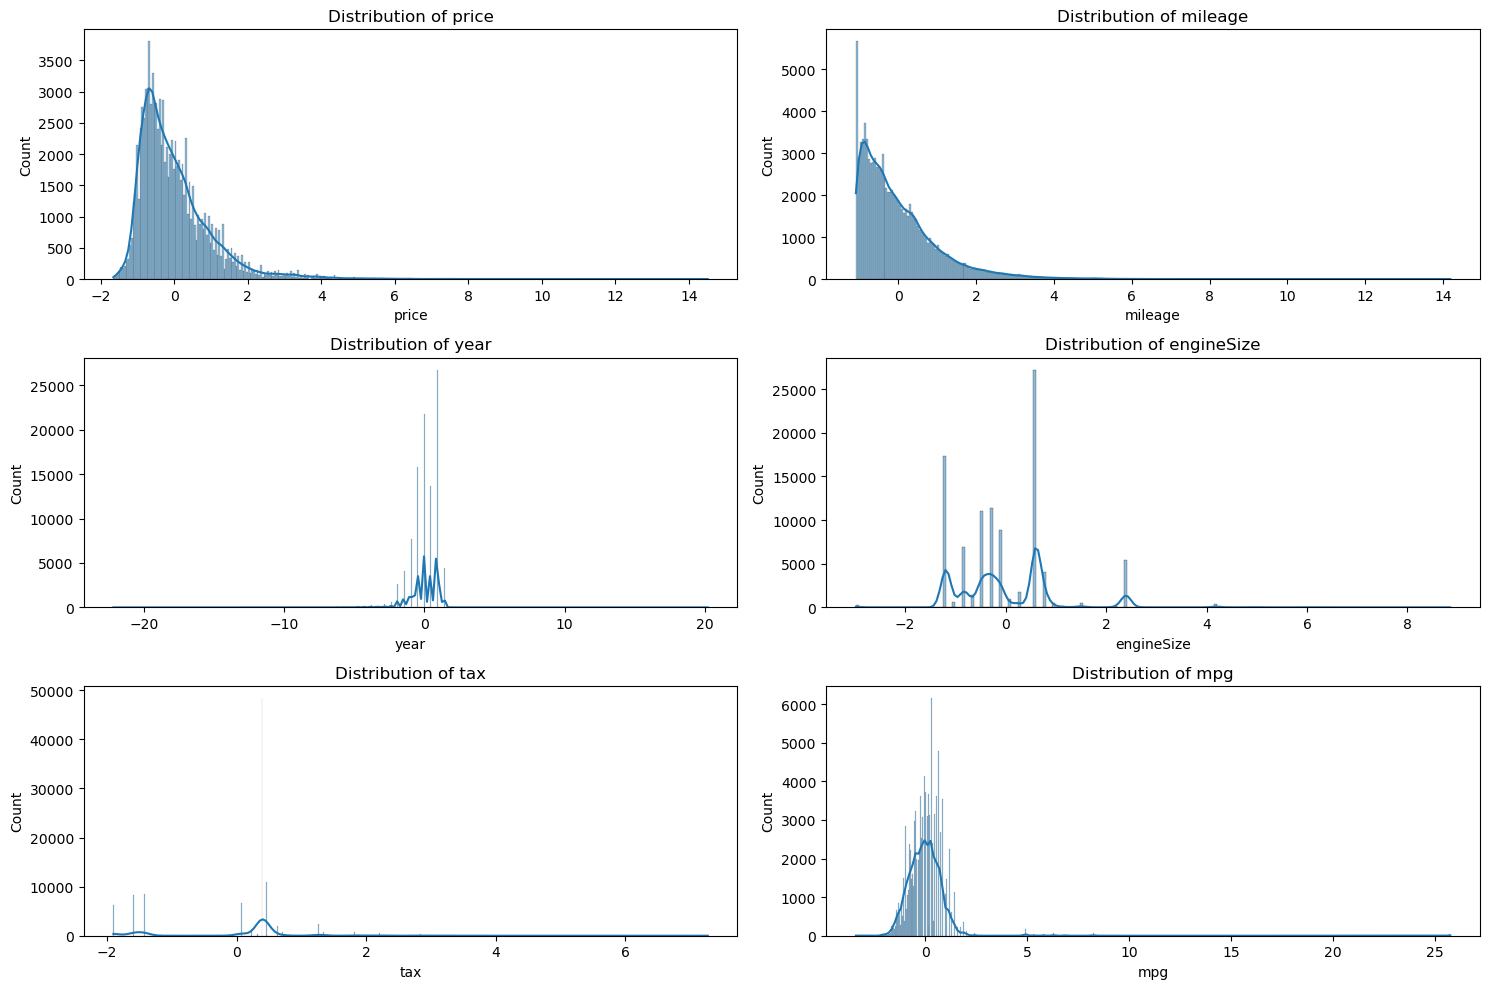

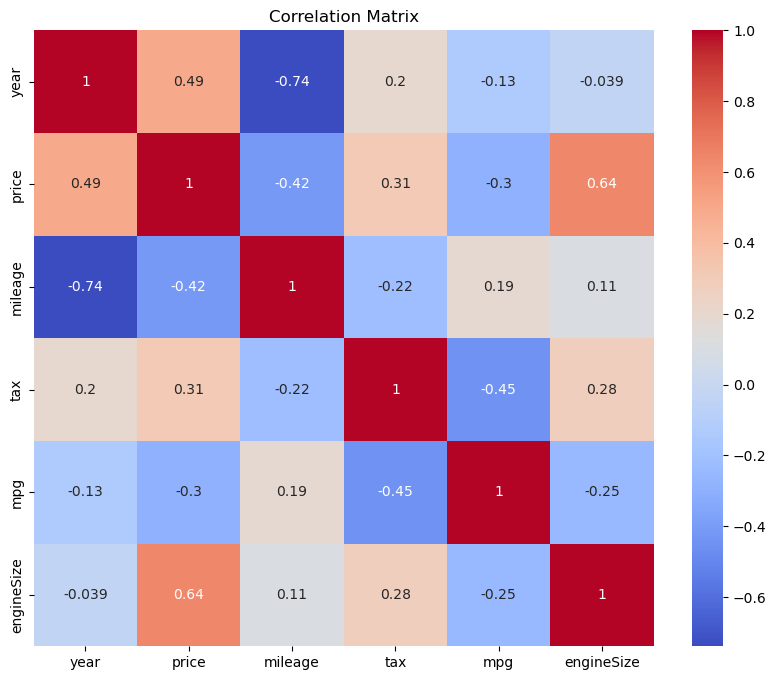

In [19]:
# Display the DataFrame
display_plot1(df_ori)

## Visual Inspection of Baseline Data Post-Preprocessing
This cell generates exploratory plots for the baseline (original) dataset after preprocessing. Visual inspection at this stage is crucial for verifying the effectiveness of preprocessing steps, identifying any remaining anomalies, and ensuring the data is suitable for robust modeling.

KeyboardInterrupt: 

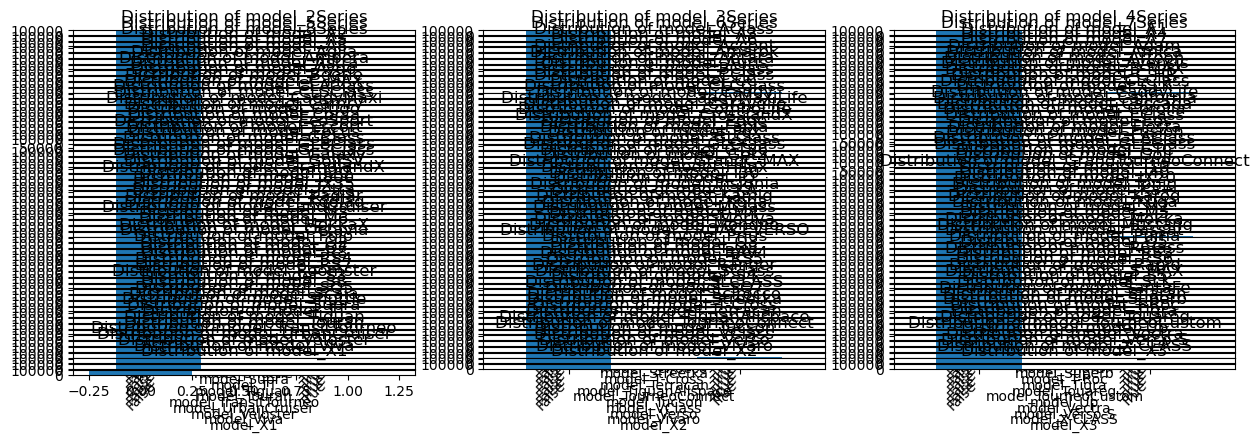

In [20]:
display_plot2(df_ori)

## Visual Inspection of Target-Transformed Data Post-Preprocessing
This cell generates exploratory plots for the target-transformed dataset after preprocessing. Such visualizations help confirm that the preprocessing and transformation steps have been applied correctly and that the data is ready for advanced modeling experiments.

In [ ]:
df_ori = outlier_detection(df_ori)
df_ori = apply_transformations(df_ori, with_standardize=False)

## Robust Preprocessing of Baseline Data Prior to Modeling
This cell applies outlier detection and Yeo-Johnson transformation to the baseline dataset. These steps are essential for mitigating the influence of extreme values and normalizing feature distributions, thereby improving the reliability and validity of subsequent machine learning analyses.

In [ ]:
# Display the DataFrame
display_plot1(df_ori)

## Post-Transformation Inspection of Baseline Data
This cell generates exploratory plots for the baseline dataset after robust preprocessing (outlier handling and transformation). This inspection step ensures that the data is well-conditioned for modeling and that preprocessing has achieved the intended effects.

In [ ]:
display_plot2(df_ori)

## Final Outlier and Distribution Check for Baseline Data
This cell generates boxplots for the baseline dataset after all preprocessing steps. This final check ensures that outliers have been effectively managed and that the data distributions are appropriate for machine learning modeling.

In [ ]:
X = df_ori.drop('price', axis=1)
Y = df_ori['price']

X_train_ori, y_train_ori, X_val_ori, y_val_ori, X_test_ori, y_test_ori = train_val_test_split(df_ori, target_col='price')

## Partitioning Baseline Data for Modeling
This cell splits the preprocessed baseline dataset into training, validation, and test sets. Proper partitioning is essential for unbiased model training, hyperparameter tuning, and performance evaluation.

In [ ]:
X_train_ori, X_val_ori, X_test_ori = perform_feature_selection(X_train_ori,
                                                               X_val_ori,
                                                               X_test_ori,
                                                               y_train_ori)

## Dimensionality Reduction and Feature Selection for Baseline Data
This cell applies Lasso-based feature selection to the baseline dataset. These steps reduce dimensionality, mitigate overfitting, and enhance model interpretability prior to training.

In [ ]:
models_ori, param_grids_ori = initilize_model_param()

## Model Initialization and Hyperparameter Setup for Baseline Data
This cell initializes the suite of regression models and their hyperparameter grids for the baseline dataset. Systematic model selection and tuning are essential for identifying the most effective algorithms for the prediction task.

In [ ]:
best_estimators_ori = perform_grid_search(models_ori, param_grids_ori,
                                          X_train_ori, y_train_ori,
                                          X_val_ori, y_val_ori)

## Systematic Model Optimization for Baseline Data
This cell performs grid search with cross-validation to optimize the hyperparameters of each candidate model for the baseline dataset. This systematic approach ensures that the best-performing models are selected based on rigorous validation.

In [ ]:
get_model_results_ori = get_model_results(best_estimators_ori, X_test_ori,
                                          y_test_ori)
display(get_model_results_ori)

## Rigorous Model Assessment for Baseline Data
This cell evaluates the performance of the optimized baseline models on the test set using multiple metrics. Comprehensive assessment ensures robust, unbiased comparison and supports transparent scientific reporting.

In [ ]:
plot_model_results(get_model_results_ori)

# Conclusion
This notebook demonstrates a rigorous, reproducible workflow for car price prediction using a variety of machine learning models and preprocessing strategies. The experiments systematically compared baseline models with those incorporating target transformation, dimensionality reduction, and robust outlier handling. Results from the comparative performance visualizations indicate that advanced preprocessing steps—such as Yeo-Johnson transformation, feature selection, and target transformation—can substantially improve model accuracy and generalization, as measured by R-squared and error metrics on the test set.

Among the evaluated models, ensemble methods (such as Random Forest and XGBoost) consistently outperformed linear and single-tree models, particularly when combined with appropriate feature engineering and hyperparameter tuning. The use of target transformation further enhanced predictive performance, highlighting the importance of addressing target distribution skewness in regression tasks.

These findings underscore the value of a comprehensive, methodical approach to data preparation and model selection in applied machine learning research. The workflow and results presented here provide a robust foundation for future studies and practical applications in predictive modeling of structured tabular data.